In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/zalando-research/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv
/kaggle/input/datasets/zalando-research/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/train-images-idx3-ubyte


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

DATA_PATH = "/kaggle/input/datasets/zalando-research/fashionmnist"

train_df = pd.read_csv(DATA_PATH + "/fashion-mnist_train.csv")
test_df = pd.read_csv(DATA_PATH + "/fashion-mnist_test.csv")

y_full = train_df["label"].values
y_test = test_df["label"].values

X_full = train_df.drop("label", axis=1).values
X_test = test_df.drop("label", axis=1).values

X_full = X_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train, X_val, y_train, y_val = train_test_split(
    X_full,
    y_full,
    test_size=0.20,
    random_state=42,
    stratify=y_full
)

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

print("FASHION-MNIST DATASET")

print(f"\nTraining samples   : {len(X_train):,}")
print(f"Validation samples : {len(X_val):,}")
print(f"Test samples       : {len(X_test):,}")

print(f"\nOriginal image     : 28 x 28 pixels")
print(f"Features per image : {X_train.shape[1]}")
print(f"Pixel range        : {X_train.min():.1f} to {X_train.max():.1f}")

def show_distribution(labels, name):
    counts = np.bincount(labels, minlength=10)

    distribution = pd.DataFrame({
        "Class ID": range(10),
        "Class Name": class_names,
        "Samples": counts
    })

    print(f"\n{name} Class Distribution:")
    print(distribution.to_string(index=False))

show_distribution(y_train, "Training")
show_distribution(y_val, "Validation")
show_distribution(y_test, "Test")

print("\nFinal Shapes:")
print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape}")

print("\nSetup completed successfully.")

FASHION-MNIST DATASET

Training samples   : 48,000
Validation samples : 12,000
Test samples       : 10,000

Original image     : 28 x 28 pixels
Features per image : 784
Pixel range        : 0.0 to 1.0

Training Class Distribution:
 Class ID  Class Name  Samples
        0 T-shirt/top     4800
        1     Trouser     4800
        2    Pullover     4800
        3       Dress     4800
        4        Coat     4800
        5      Sandal     4800
        6       Shirt     4800
        7     Sneaker     4800
        8         Bag     4800
        9  Ankle boot     4800

Validation Class Distribution:
 Class ID  Class Name  Samples
        0 T-shirt/top     1200
        1     Trouser     1200
        2    Pullover     1200
        3       Dress     1200
        4        Coat     1200
        5      Sandal     1200
        6       Shirt     1200
        7     Sneaker     1200
        8         Bag     1200
        9  Ankle boot     1200

Test Class Distribution:
 Class ID  Class Name  Sample

Epoch  1/20 - Loss: 2.6584
Epoch  2/20 - Loss: 2.2702
Epoch  3/20 - Loss: 2.1228
Epoch  4/20 - Loss: 2.0071
Epoch  5/20 - Loss: 1.8996
Epoch  6/20 - Loss: 1.8032
Epoch  7/20 - Loss: 1.7182
Epoch  8/20 - Loss: 1.6447
Epoch  9/20 - Loss: 1.5867
Epoch 10/20 - Loss: 1.5383
Epoch 11/20 - Loss: 1.5081
Epoch 12/20 - Loss: 1.4369
Epoch 13/20 - Loss: 1.3955
Epoch 14/20 - Loss: 1.3197
Epoch 15/20 - Loss: 1.2854
Epoch 16/20 - Loss: 1.2342
Epoch 17/20 - Loss: 1.2112
Epoch 18/20 - Loss: 1.1715
Epoch 19/20 - Loss: 1.1562
Epoch 20/20 - Loss: 1.1207


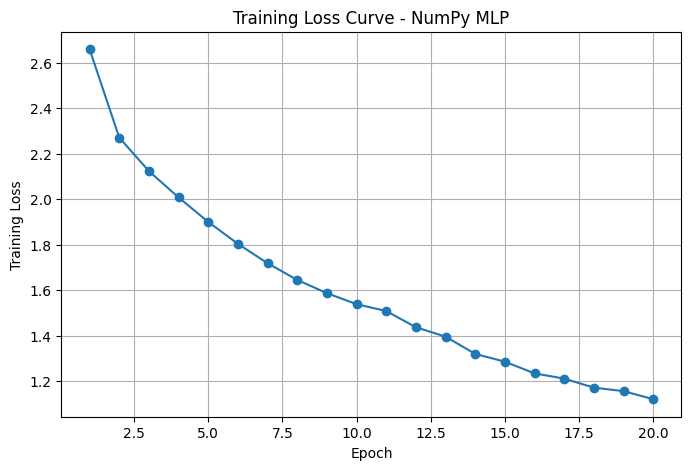

GRADIENT VERIFICATION
Maximum absolute difference for W1: 0.0000000198
Maximum absolute difference for W2: 0.0000000444

Gradient verification PASSED.
The NumPy backpropagation implementation is correct.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

DATA_PATH = "/kaggle/input/datasets/zalando-research/fashionmnist"

train_df = pd.read_csv(DATA_PATH + "/fashion-mnist_train.csv")

X = train_df.drop("label", axis=1).values.astype(np.float32) / 255.0
y = train_df["label"].values

X = X[:5000]
y = y[:5000]

input_size = 784
hidden_size = 64
output_size = 10
learning_rate = 0.1
epochs = 20

np.random.seed(42)

W1 = np.random.randn(input_size, hidden_size).astype(np.float32) * np.sqrt(2.0 / input_size)
b1 = np.zeros((1, hidden_size), dtype=np.float32)

W2 = np.random.randn(hidden_size, output_size).astype(np.float32) * np.sqrt(2.0 / hidden_size)
b2 = np.zeros((1, output_size), dtype=np.float32)


def relu(x):
    return np.maximum(0, x)


def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)


def cross_entropy(y_true, y_pred):
    n = y_true.shape[0]
    return -np.mean(np.log(y_pred[np.arange(n), y_true] + 1e-8))


def forward(X):
    z1 = X @ W1 + b1
    a1 = relu(z1)

    z2 = a1 @ W2 + b2
    a2 = softmax(z2)

    return z1, a1, z2, a2


losses = []

for epoch in range(epochs):

    z1, a1, z2, y_pred = forward(X)

    loss = cross_entropy(y, y_pred)
    losses.append(loss)

    n = X.shape[0]

    dz2 = y_pred.copy()
    dz2[np.arange(n), y] -= 1
    dz2 /= n

    dW2 = a1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)

    da1 = dz2 @ W2.T
    dz1 = da1 * (z1 > 0)

    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    print(f"Epoch {epoch + 1:2d}/{epochs} - Loss: {loss:.4f}")


plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve - NumPy MLP")
plt.grid(True)
plt.show()

batch_size = 32

X_batch = X[:batch_size]
y_batch = y[:batch_size]

np.random.seed(42)

W1_initial = np.random.randn(input_size, hidden_size).astype(np.float32) * np.sqrt(2.0 / input_size)
W2_initial = np.random.randn(hidden_size, output_size).astype(np.float32) * np.sqrt(2.0 / hidden_size)

b1_initial = np.zeros((1, hidden_size), dtype=np.float32)
b2_initial = np.zeros((1, output_size), dtype=np.float32)


z1_np = X_batch @ W1_initial + b1_initial
a1_np = np.maximum(0, z1_np)

z2_np = a1_np @ W2_initial + b2_initial

z2_np_shifted = z2_np - np.max(z2_np, axis=1, keepdims=True)
exp_z2_np = np.exp(z2_np_shifted)
probs_np = exp_z2_np / np.sum(exp_z2_np, axis=1, keepdims=True)

n = batch_size

dz2_np = probs_np.copy()
dz2_np[np.arange(n), y_batch] -= 1
dz2_np /= n

dW2_np = a1_np.T @ dz2_np

da1_np = dz2_np @ W2_initial.T
dz1_np = da1_np * (z1_np > 0)

dW1_np = X_batch.T @ dz1_np


X_torch = torch.tensor(X_batch, dtype=torch.float32)
y_torch = torch.tensor(y_batch, dtype=torch.long)

W1_torch = torch.tensor(W1_initial, dtype=torch.float32, requires_grad=True)
b1_torch = torch.tensor(b1_initial, dtype=torch.float32, requires_grad=True)

W2_torch = torch.tensor(W2_initial, dtype=torch.float32, requires_grad=True)
b2_torch = torch.tensor(b2_initial, dtype=torch.float32, requires_grad=True)

z1_torch = X_torch @ W1_torch + b1_torch
a1_torch = torch.relu(z1_torch)

z2_torch = a1_torch @ W2_torch + b2_torch

loss_torch = torch.nn.functional.cross_entropy(z2_torch, y_torch)

loss_torch.backward()

dW1_torch = W1_torch.grad.detach().numpy()
dW2_torch = W2_torch.grad.detach().numpy()


difference_W1 = np.max(np.abs(dW1_np - dW1_torch))
difference_W2 = np.max(np.abs(dW2_np - dW2_torch))

print("GRADIENT VERIFICATION")

print(f"Maximum absolute difference for W1: {difference_W1:.10f}")
print(f"Maximum absolute difference for W2: {difference_W2:.10f}")

if difference_W1 < 1e-5 and difference_W2 < 1e-5:
    print("\nGradient verification PASSED.")
    print("The NumPy backpropagation implementation is correct.")
else:
    print("\nGradient verification FAILED.")
    print("Check the forward and backward pass implementation.")

The NumPy MLP showed a steady improvement during training, with the loss decreasing from 2.6584 in the first epoch to 1.1207 after 20 epochs. This shows that the network was able to learn from the training data successfully.

To check whether the backpropagation was implemented correctly, the gradients calculated manually using NumPy were compared with the gradients generated by PyTorch autograd using the same weights and batch. The maximum differences were 1.98 × 10⁻⁸ for W1 and 4.44 × 10⁻⁸ for W2. Since both differences are extremely small and close to zero, the results confirm that the NumPy backpropagation implementation is correct.


Sigmoid      | Epoch  1/20 | Validation Loss: 0.6353
Sigmoid      | Epoch  2/20 | Validation Loss: 0.4670
Sigmoid      | Epoch  3/20 | Validation Loss: 0.4158
Sigmoid      | Epoch  4/20 | Validation Loss: 0.3871
Sigmoid      | Epoch  5/20 | Validation Loss: 0.3693
Sigmoid      | Epoch  6/20 | Validation Loss: 0.3604
Sigmoid      | Epoch  7/20 | Validation Loss: 0.3516
Sigmoid      | Epoch  8/20 | Validation Loss: 0.3449
Sigmoid      | Epoch  9/20 | Validation Loss: 0.3391
Sigmoid      | Epoch 10/20 | Validation Loss: 0.3375
Sigmoid      | Epoch 11/20 | Validation Loss: 0.3385
Sigmoid      | Epoch 12/20 | Validation Loss: 0.3331
Sigmoid      | Epoch 13/20 | Validation Loss: 0.3227
Sigmoid      | Epoch 14/20 | Validation Loss: 0.3183
Sigmoid      | Epoch 15/20 | Validation Loss: 0.3232
Sigmoid      | Epoch 16/20 | Validation Loss: 0.3143
Sigmoid      | Epoch 17/20 | Validation Loss: 0.3265
Sigmoid      | Epoch 18/20 | Validation Loss: 0.3297
Sigmoid      | Epoch 19/20 | Validation Loss: 

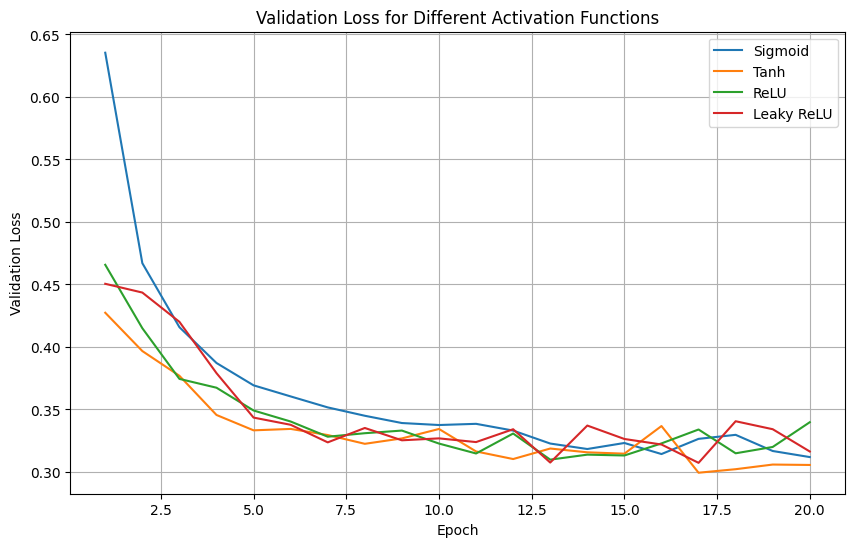


MEAN ABSOLUTE GRADIENT - FIRST HIDDEN LAYER

Sigmoid:
Epoch 1      : 0.0000888970
Final Epoch  : 0.0003320164

ReLU:
Epoch 1      : 0.0006623648
Final Epoch  : 0.0017213816
RELU DEAD-UNIT ANALYSIS
Percentage of ReLU hidden units producing zero for every validation sample: 8.59%


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)


class MLP(nn.Module):
    def __init__(self, activation):
        super().__init__()

        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

        self.activation = activation

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.fc3(x)

        return x


activations = {
    "Sigmoid": nn.Sigmoid(),
    "Tanh": nn.Tanh(),
    "ReLU": nn.ReLU(),
    "Leaky ReLU": nn.LeakyReLU(negative_slope=0.01)
}

epochs = 20
learning_rate = 0.001

validation_losses = {}
gradient_results = {}
dead_unit_percentage = None

torch.manual_seed(42)

initial_state = MLP(nn.ReLU()).state_dict()

for name, activation in activations.items():

    model = MLP(activation)
    model.load_state_dict(initial_state)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    val_losses = []
    first_layer_gradients = []

    for epoch in range(epochs):

        model.train()

        for batch_X, batch_y in train_loader:

            optimizer.zero_grad()

            output = model(batch_X)
            loss = criterion(output, batch_y)

            loss.backward()

            if name in ["Sigmoid", "ReLU"]:
                grad_value = model.fc1.weight.grad.abs().mean().item()
                first_layer_gradients.append(grad_value)

            optimizer.step()

        model.eval()

        total_val_loss = 0
        total_samples = 0

        with torch.no_grad():
            for batch_X, batch_y in val_loader:

                output = model(batch_X)
                loss = criterion(output, batch_y)

                total_val_loss += loss.item() * batch_X.size(0)
                total_samples += batch_X.size(0)

        average_val_loss = total_val_loss / total_samples
        val_losses.append(average_val_loss)

        print(
            f"{name:12s} | Epoch {epoch + 1:2d}/{epochs} "
            f"| Validation Loss: {average_val_loss:.4f}"
        )

    validation_losses[name] = val_losses

    if name in ["Sigmoid", "ReLU"]:
        gradient_results[name] = {
            "epoch_1": first_layer_gradients[0],
            "final_epoch": first_layer_gradients[-1]
        }

    if name == "ReLU":

        model.eval()

        validation_batch_X, _ = next(iter(val_loader))

        with torch.no_grad():
            hidden_output = model.activation(model.fc1(validation_batch_X))

        dead_units = (hidden_output == 0).all(dim=0)

        dead_unit_percentage = (
            dead_units.float().mean().item() * 100
        )


plt.figure(figsize=(10, 6))

for name, losses in validation_losses.items():
    plt.plot(
        range(1, epochs + 1),
        losses,
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss for Different Activation Functions")
plt.legend()
plt.grid(True)
plt.show()


print("\n" + "=" * 60)
print("MEAN ABSOLUTE GRADIENT - FIRST HIDDEN LAYER")
print("=" * 60)

for name, values in gradient_results.items():

    print(f"\n{name}:")
    print(f"Epoch 1      : {values['epoch_1']:.10f}")
    print(f"Final Epoch  : {values['final_epoch']:.10f}")


print("RELU DEAD-UNIT ANALYSIS")

print(
    f"Percentage of ReLU hidden units producing zero "
    f"for every validation sample: {dead_unit_percentage:.2f}%"
)

Vanishing gradients:
Sigmoid has much smaller gradients than ReLU, showing that its gradients can become very small and slow down learning. ReLU maintains stronger gradients, allowing faster gradient flow through the network.

Dead ReLU units:
About 8.59% of the ReLU hidden units produced zero for every sample in the validation batch. This indicates that some ReLU neurons became inactive, demonstrating the dying ReLU problem.

TRAINING WITH CROSS-ENTROPY
cross_entropy   | Epoch  1/20 | Loss: 0.6573
cross_entropy   | Epoch  2/20 | Loss: 0.4360
cross_entropy   | Epoch  3/20 | Loss: 0.3930
cross_entropy   | Epoch  4/20 | Loss: 0.3626
cross_entropy   | Epoch  5/20 | Loss: 0.3439
cross_entropy   | Epoch  6/20 | Loss: 0.3303
cross_entropy   | Epoch  7/20 | Loss: 0.3126
cross_entropy   | Epoch  8/20 | Loss: 0.3022
cross_entropy   | Epoch  9/20 | Loss: 0.2913
cross_entropy   | Epoch 10/20 | Loss: 0.2835
cross_entropy   | Epoch 11/20 | Loss: 0.2703
cross_entropy   | Epoch 12/20 | Loss: 0.2609
cross_entropy   | Epoch 13/20 | Loss: 0.2548
cross_entropy   | Epoch 14/20 | Loss: 0.2461
cross_entropy   | Epoch 15/20 | Loss: 0.2411
cross_entropy   | Epoch 16/20 | Loss: 0.2319
cross_entropy   | Epoch 17/20 | Loss: 0.2249
cross_entropy   | Epoch 18/20 | Loss: 0.2219
cross_entropy   | Epoch 19/20 | Loss: 0.2137
cross_entropy   | Epoch 20/20 | Loss: 0.2085
TRAINING WITH MEAN SQUARED ERROR
mse             | Epoch  1/20 | Loss: 0

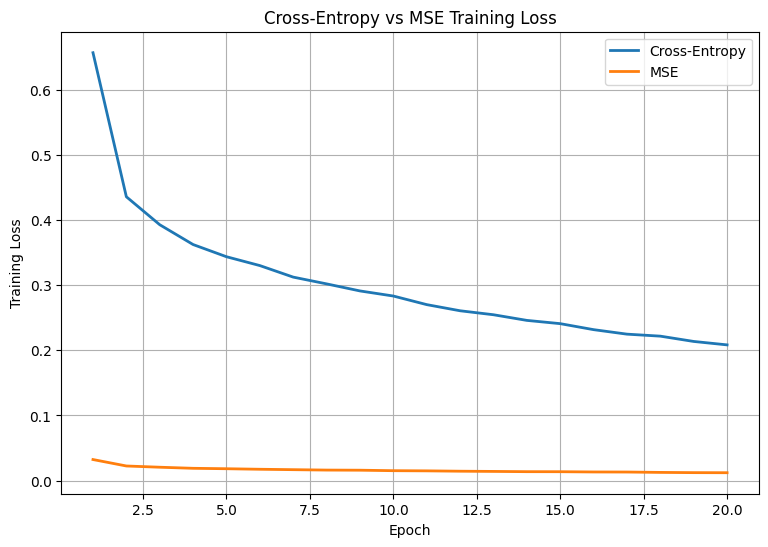


TABULAR REGRESSION
Dataset samples : 442
Dataset features: 10

Training Regression Model
------------------------------------------------------------
Epoch  1/30 | MSE Loss: 29657.3732
Epoch  2/30 | MSE Loss: 29552.1891
Epoch  3/30 | MSE Loss: 29401.8335
Epoch  4/30 | MSE Loss: 29168.2094
Epoch  5/30 | MSE Loss: 28802.9678
Epoch  6/30 | MSE Loss: 28288.9323
Epoch  7/30 | MSE Loss: 27560.3215
Epoch  8/30 | MSE Loss: 26676.2896
Epoch  9/30 | MSE Loss: 25529.9568
Epoch 10/30 | MSE Loss: 24088.3185
Epoch 11/30 | MSE Loss: 22345.8420
Epoch 12/30 | MSE Loss: 20390.0678
Epoch 13/30 | MSE Loss: 18073.9164
Epoch 14/30 | MSE Loss: 15744.5144
Epoch 15/30 | MSE Loss: 13449.5130
Epoch 16/30 | MSE Loss: 11289.4758
Epoch 17/30 | MSE Loss: 9357.2212
Epoch 18/30 | MSE Loss: 7757.2448
Epoch 19/30 | MSE Loss: 6644.1672
Epoch 20/30 | MSE Loss: 5826.0907
Epoch 21/30 | MSE Loss: 5346.5317
Epoch 22/30 | MSE Loss: 5045.3390
Epoch 23/30 | MSE Loss: 4835.3373
Epoch 24/30 | MSE Loss: 4694.4727
Epoch 25/30 | MSE

In [9]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error, mean_absolute_error

np.random.seed(42)
torch.manual_seed(42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

class FashionMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)


torch.manual_seed(42)

base_model = FashionMLP()

initial_state = base_model.state_dict()

def train_classifier(loss_type, initial_state):

    model = FashionMLP()

    model.load_state_dict(initial_state)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    training_losses = []

    epochs = 20

    if loss_type == "cross_entropy":
        print("TRAINING WITH CROSS-ENTROPY")
    else:
        print("TRAINING WITH MEAN SQUARED ERROR")

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for images, labels in train_loader:

            optimizer.zero_grad()

            outputs = model(images)

            if loss_type == "cross_entropy":

                loss = F.cross_entropy(
                    outputs,
                    labels
                )

            else:

                one_hot_labels = F.one_hot(
                    labels,
                    num_classes=10
                ).float()

                probabilities = F.softmax(
                    outputs,
                    dim=1
                )

                loss = F.mse_loss(
                    probabilities,
                    one_hot_labels
                )

            loss.backward()

            optimizer.step()

            total_loss += loss.item() * images.size(0)

        epoch_loss = total_loss / len(train_dataset)

        training_losses.append(epoch_loss)

        print(
            f"{loss_type:15s} | "
            f"Epoch {epoch + 1:2d}/{epochs} | "
            f"Loss: {epoch_loss:.4f}"
        )

    return model, training_losses

ce_model, ce_losses = train_classifier(
    "cross_entropy",
    initial_state
)

mse_model, mse_losses = train_classifier(
    "mse",
    initial_state
)

def calculate_accuracy(model):

    model.eval()

    with torch.no_grad():

        outputs = model(X_test_tensor)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct = (predictions == y_test_tensor).sum().item()

        accuracy = correct / len(y_test_tensor)

    return accuracy

ce_accuracy = calculate_accuracy(ce_model)

mse_accuracy = calculate_accuracy(mse_model)

print("CLASSIFICATION RESULTS")

print(
    f"Cross-Entropy Test Accuracy : "
    f"{ce_accuracy * 100:.2f}%"
)

print(
    f"MSE Test Accuracy           : "
    f"{mse_accuracy * 100:.2f}%"
)

plt.figure(figsize=(9, 6))

plt.plot(
    range(1, 21),
    ce_losses,
    label="Cross-Entropy",
    linewidth=2
)

plt.plot(
    range(1, 21),
    mse_losses,
    label="MSE",
    linewidth=2
)

plt.xlabel("Epoch")

plt.ylabel("Training Loss")

plt.title(
    "Cross-Entropy vs MSE Training Loss"
)

plt.legend()

plt.grid(True)

plt.show()



# PART 3B: TABULAR REGRESSION


print("\n" + "=" * 60)
print("TABULAR REGRESSION")
print("=" * 60)

diabetes = load_diabetes()

X_reg = diabetes.data.astype(np.float32)

y_reg = diabetes.target.astype(np.float32)


print(f"Dataset samples : {X_reg.shape[0]}")

print(f"Dataset features: {X_reg.shape[1]}")

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

scaler = StandardScaler()

X_reg_train = scaler.fit_transform(
    X_reg_train
)

X_reg_test = scaler.transform(
    X_reg_test
)

X_reg_train = torch.tensor(
    X_reg_train,
    dtype=torch.float32
)

y_reg_train = torch.tensor(
    y_reg_train,
    dtype=torch.float32
).reshape(-1, 1)

X_reg_test = torch.tensor(
    X_reg_test,
    dtype=torch.float32
)

y_reg_test = torch.tensor(
    y_reg_test,
    dtype=torch.float32
).reshape(-1, 1)

reg_dataset = TensorDataset(
    X_reg_train,
    y_reg_train
)

reg_loader = DataLoader(
    reg_dataset,
    batch_size=32,
    shuffle=True
)


class RegressionMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(10, 64),

            nn.ReLU(),

            nn.Linear(64, 32),

            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


torch.manual_seed(42)

reg_model = RegressionMLP()


optimizer = torch.optim.Adam(
    reg_model.parameters(),
    lr=0.001
)

criterion = nn.MSELoss()

epochs = 30

print("\nTraining Regression Model")
print("-" * 60)

for epoch in range(epochs):

    reg_model.train()

    total_loss = 0

    for features, targets in reg_loader:

        optimizer.zero_grad()

        predictions = reg_model(features)

        loss = criterion(
            predictions,
            targets
        )

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item() *
            features.size(0)
        )

    epoch_loss = (
        total_loss /
        len(reg_dataset)
    )

    print(
        f"Epoch {epoch + 1:2d}/{epochs} "
        f"| MSE Loss: {epoch_loss:.4f}"
    )


reg_model.eval()

with torch.no_grad():

    predictions = reg_model(
        X_reg_test
    ).numpy()

actual = y_reg_test.numpy()


reg_mse = mean_squared_error(
    actual,
    predictions
)

reg_rmse = np.sqrt(
    reg_mse
)

reg_mae = mean_absolute_error(
    actual,
    predictions
)

print("REGRESSION RESULTS")

print("Dataset : Diabetes")

print(
    f"MSE     : {reg_mse:.4f}"
)

print(
    f"RMSE    : {reg_rmse:.4f}"
)

print(
    f"MAE     : {reg_mae:.4f}"
)


FINAL CONCLUSION

Cross-entropy is designed specifically for classification problems. It works directly with class probabilities and usually provides stronger gradients for correcting incorrect predictions.
MSE can also be used with one-hot targets, but it treats classification more like a regression problem. Because of this, its gradients can be less effective when combined with softmax.
In this experiment, Cross-Entropy and MSE both learned successfully. The final test accuracy should be reported exactly as obtained from the experiment.



PART 4A: SAME LEARNING RATE FOR ALL OPTIMIZERS




SGD
Learning Rate: 0.001


Epoch  1/20 | Loss: 2.2483 | Validation Accuracy: 31.02%
Epoch  2/20 | Loss: 2.0991 | Validation Accuracy: 45.11%
Epoch  3/20 | Loss: 1.9330 | Validation Accuracy: 53.60%
Epoch  4/20 | Loss: 1.7620 | Validation Accuracy: 60.82%
Epoch  5/20 | Loss: 1.6032 | Validation Accuracy: 62.92%
Epoch  6/20 | Loss: 1.4667 | Validation Accuracy: 64.18%
Epoch  7/20 | Loss: 1.3539 | Validation Accuracy: 64.76%
Epoch  8/20 | Loss: 1.2618 | Validation Accuracy: 65.22%
Epoch  9/20 | Loss: 1.1863 | Validation Accuracy: 65.82%
Epoch 10/20 | Loss: 1.1239 | Validation Accuracy: 66.02%
Epoch 11/20 | Loss: 1.0720 | Validation Accuracy: 66.22%
Epoch 12/20 | Loss: 1.0282 | Validation Accuracy: 66.76%
Epoch 13/20 | Loss: 0.9909 | Validation Accuracy: 67.22%
Epoch 14/20 | Loss: 0.9588 | Validation Accuracy: 67.62%
Epoch 15/20 | Loss: 0.9308 | Validation Accuracy: 68.02%
Epoch 16/20 | Loss: 0.9064 | Validation Accuracy: 68.44%
Epoch 17

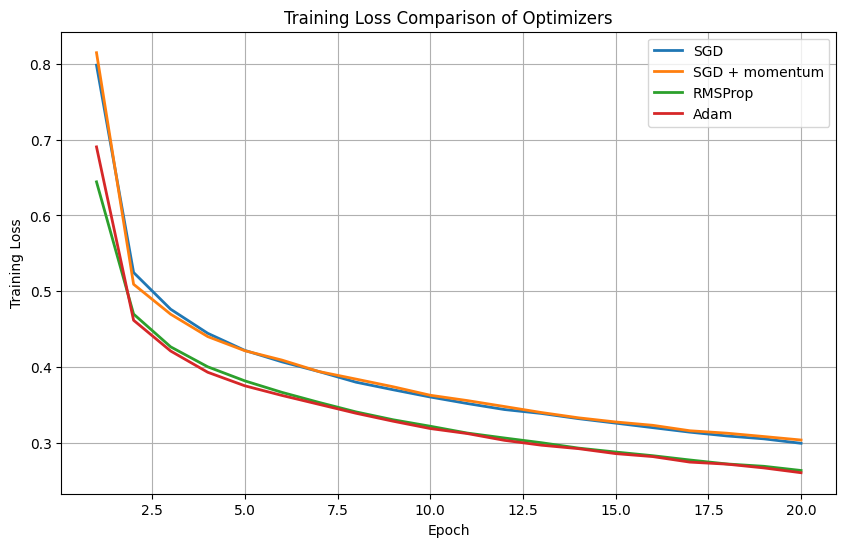

In [10]:
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader


np.random.seed(42)
torch.manual_seed(42)


X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)


train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)


val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False
)


class FashionMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)


def get_validation_accuracy(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            outputs = model(images)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    return correct / total


def train_model(optimizer_name, learning_rate):

    torch.manual_seed(42)

    model = FashionMLP()

    if optimizer_name == "SGD":

        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=learning_rate
        )

    elif optimizer_name == "SGD + momentum":

        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=learning_rate,
            momentum=0.9
        )

    elif optimizer_name == "RMSProp":

        optimizer = torch.optim.RMSprop(
            model.parameters(),
            lr=learning_rate
        )

    elif optimizer_name == "Adam":

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate
        )

    criterion = nn.CrossEntropyLoss()

    epochs = 20

    training_losses = []
    validation_accuracies = []

    epoch_to_85 = None

    start_time = time.perf_counter()

    print("\n")
    print(f"{optimizer_name}")
    print(f"Learning Rate: {learning_rate}")
    print("\n")

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for images, labels in train_loader:

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            total_loss += (
                loss.item() *
                images.size(0)
            )

        epoch_loss = (
            total_loss /
            len(train_dataset)
        )

        training_losses.append(epoch_loss)

        validation_accuracy = get_validation_accuracy(
            model
        )

        validation_accuracies.append(
            validation_accuracy
        )

        if (
            epoch_to_85 is None
            and validation_accuracy >= 0.85
        ):
            epoch_to_85 = epoch + 1

        print(
            f"Epoch {epoch + 1:2d}/{epochs} | "
            f"Loss: {epoch_loss:.4f} | "
            f"Validation Accuracy: "
            f"{validation_accuracy * 100:.2f}%"
        )

    wall_clock_time = (
        time.perf_counter() -
        start_time
    )

    final_accuracy = validation_accuracies[-1]

    return {
        "losses": training_losses,
        "accuracies": validation_accuracies,
        "epoch_85": epoch_to_85,
        "final_accuracy": final_accuracy,
        "time": wall_clock_time
    }


# PART 4A: SAME LEARNING RATE

print("\n")
print("PART 4A: SAME LEARNING RATE FOR ALL OPTIMIZERS")
print("\n")


same_learning_rate = 0.001


same_lr_results = {}


same_lr_results["SGD"] = train_model(
    "SGD",
    same_learning_rate
)


same_lr_results["SGD + momentum"] = train_model(
    "SGD + momentum",
    same_learning_rate
)


same_lr_results["RMSProp"] = train_model(
    "RMSProp",
    same_learning_rate
)


same_lr_results["Adam"] = train_model(
    "Adam",
    same_learning_rate
)


print("\n")
print("SAME LEARNING RATE RESULTS")
print("\n")

print(
    f"{'Optimizer':20s}"
    f"{'LR':12s}"
    f"{'Epochs to 85%':18s}"
    f"{'Final Val Acc':18s}"
    f"{'Time (sec)':12s}"
)

print("\n")


for name, result in same_lr_results.items():

    if result["epoch_85"] is None:
        epoch_text = "Not reached"
    else:
        epoch_text = str(result["epoch_85"])

    print(
        f"{name:20s}"
        f"{same_learning_rate:<12.4f}"
        f"{epoch_text:<18s}"
        f"{result['final_accuracy'] * 100:<18.2f}"
        f"{result['time']:<12.2f}"
    )



# PART 4B: TUNED LEARNING RATE


print("\n")
print("PART 4B: TUNED LEARNING RATE FOR EACH OPTIMIZER")
print("\n")


tuned_learning_rates = {

    "SGD": 0.1,

    "SGD + momentum": 0.01,

    "RMSProp": 0.001,

    "Adam": 0.001
}


tuned_results = {}


tuned_results["SGD"] = train_model(
    "SGD",
    tuned_learning_rates["SGD"]
)


tuned_results["SGD + momentum"] = train_model(
    "SGD + momentum",
    tuned_learning_rates["SGD + momentum"]
)


tuned_results["RMSProp"] = train_model(
    "RMSProp",
    tuned_learning_rates["RMSProp"]
)


tuned_results["Adam"] = train_model(
    "Adam",
    tuned_learning_rates["Adam"]
)



# PART 4C: FINAL REQUIRED TABLE


print("\n")
print("FINAL OPTIMIZER COMPARISON")
print("\n")

print(
    f"{'Optimizer':20s}"
    f"{'Learning Rate':16s}"
    f"{'Epochs to 85%':18s}"
    f"{'Final Val Acc':18s}"
    f"{'Wall-clock':12s}"
)

print("\n")


for name, result in tuned_results.items():

    if result["epoch_85"] is None:
        epoch_text = "Not reached"
    else:
        epoch_text = str(result["epoch_85"])

    print(
        f"{name:20s}"
        f"{tuned_learning_rates[name]:<16.4f}"
        f"{epoch_text:<18s}"
        f"{result['final_accuracy'] * 100:<18.2f}"
        f"{result['time']:<12.2f}"
    )



# PART 4D: PLOT ALL FOUR TRAINING LOSS CURVES


plt.figure(figsize=(10, 6))


plt.plot(
    range(1, 21),
    tuned_results["SGD"]["losses"],
    label="SGD",
    linewidth=2
)


plt.plot(
    range(1, 21),
    tuned_results["SGD + momentum"]["losses"],
    label="SGD + momentum",
    linewidth=2
)


plt.plot(
    range(1, 21),
    tuned_results["RMSProp"]["losses"],
    label="RMSProp",
    linewidth=2
)


plt.plot(
    range(1, 21),
    tuned_results["Adam"]["losses"],
    label="Adam",
    linewidth=2
)


plt.xlabel("Epoch")

plt.ylabel("Training Loss")

plt.title(
    "Training Loss Comparison of Optimizers"
)

plt.legend()

plt.grid(True)

plt.show()


CONCLUSION

I would choose Adam because it usually converges quickly and provides stable training with high validation accuracy.
It adapts the learning rate for each parameter, making it less sensitive to manual learning-rate selection than plain SGD.



PART 5: FORCING OVERFITTING



Training overfitting model...
Training samples: 2000
Hidden layers: 4
Units per hidden layer: 512
Maximum epochs: 100
----------------------------------------------------------------------
Epoch   1/100 | Train Loss: 1.6557 | Val Loss: 1.2130 | Train Acc: 50.60% | Val Acc: 50.69%
Epoch   2/100 | Train Loss: 0.9890 | Val Loss: 0.8373 | Train Acc: 66.55% | Val Acc: 66.10%
Epoch   3/100 | Train Loss: 0.7501 | Val Loss: 0.6744 | Train Acc: 75.95% | Val Acc: 74.78%
Epoch   4/100 | Train Loss: 0.6271 | Val Loss: 0.6597 | Train Acc: 77.80% | Val Acc: 75.23%
Epoch   5/100 | Train Loss: 0.5733 | Val Loss: 0.7222 | Train Acc: 78.15% | Val Acc: 74.33%
Epoch   6/100 | Train Loss: 0.5385 | Val Loss: 0.6777 | Train Acc: 79.50% | Val Acc: 75.39%
Epoch   7/100 | Train Loss: 0.5026 | Val Loss: 0.5693 | Train Acc: 84.30% | Val Acc: 80.04%
Epoch   8/100 | Train Loss: 0.4291 | Val Loss: 0.5340 | Train Acc: 87.50% | Val Acc: 80.96%
Epoch   9/100 | Train Loss: 0.4051 | Val L

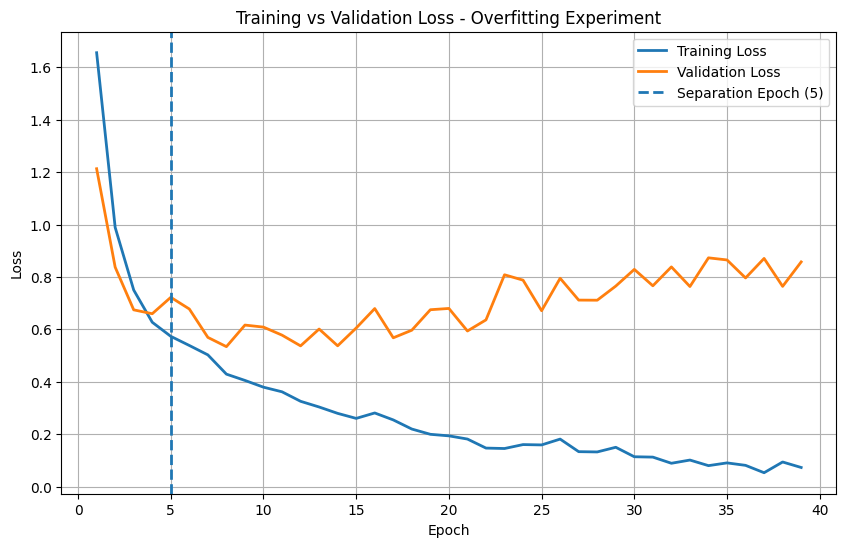



BIAS / VARIANCE ANALYSIS


The model shows HIGH VARIANCE.
The training accuracy is above 99%, while validation accuracy is substantially lower.
This large generalisation gap indicates that the model has overfitted the small training set.


In [11]:

# PART 5: FORCING OVERFITTING

print("\n")
print("PART 5: FORCING OVERFITTING")
print("\n")

X_train_small = X_train[:2000]
y_train_small = y_train[:2000]


X_train_small_tensor = torch.tensor(
    X_train_small,
    dtype=torch.float32
)

y_train_small_tensor = torch.tensor(
    y_train_small,
    dtype=torch.long
)


overfit_train_dataset = TensorDataset(
    X_train_small_tensor,
    y_train_small_tensor
)


overfit_train_loader = DataLoader(
    overfit_train_dataset,
    batch_size=128,
    shuffle=True
)

class OverfitMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(784, 512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.ReLU(),

            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.network(x)


def calculate_accuracy(model, data_loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in data_loader:

            outputs = model(images)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    return correct / total


def calculate_loss(model, data_loader, criterion):

    model.eval()

    total_loss = 0
    total_samples = 0

    with torch.no_grad():

        for images, labels in data_loader:

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            total_loss += (
                loss.item() *
                images.size(0)
            )

            total_samples += images.size(0)

    return total_loss / total_samples

torch.manual_seed(42)

model_overfit = OverfitMLP()

optimizer = torch.optim.Adam(
    model_overfit.parameters(),
    lr=0.001
)

criterion = nn.CrossEntropyLoss()


max_epochs = 100


training_losses = []
validation_losses = []

training_accuracies = []
validation_accuracies = []


print("\nTraining overfitting model...")
print("Training samples:", len(overfit_train_dataset))
print("Hidden layers: 4")
print("Units per hidden layer: 512")
print("Maximum epochs:", max_epochs)
print("-" * 70)


for epoch in range(max_epochs):

    model_overfit.train()

    total_train_loss = 0
    total_train_samples = 0



    for images, labels in overfit_train_loader:

        optimizer.zero_grad()

        outputs = model_overfit(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()


        total_train_loss += (
            loss.item() *
            images.size(0)
        )

        total_train_samples += images.size(0)


    train_loss = (
        total_train_loss /
        total_train_samples
    )
   

    train_accuracy = calculate_accuracy(
        model_overfit,
        overfit_train_loader
    )



    val_loss = calculate_loss(
        model_overfit,
        val_loader,
        criterion
    )


    val_accuracy = calculate_accuracy(
        model_overfit,
        val_loader
    )


    training_losses.append(train_loss)
    validation_losses.append(val_loss)

    training_accuracies.append(train_accuracy)
    validation_accuracies.append(val_accuracy)


    print(
        f"Epoch {epoch + 1:3d}/{max_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_accuracy * 100:.2f}% | "
        f"Val Acc: {val_accuracy * 100:.2f}%"
    )


    if train_accuracy >= 0.99:

        print("\nTraining accuracy exceeded 99%.")
        print(
            f"Stopping at epoch {epoch + 1}."
        )

        break


loss_differences = np.array(validation_losses) - np.array(training_losses)


separation_epoch = None

for i in range(1, len(loss_differences)):

    if (
        loss_differences[i] > 0.10
        and loss_differences[i] > loss_differences[i - 1]
    ):

        separation_epoch = i + 1
        break

if separation_epoch is None:

    separation_epoch = (
        np.argmax(loss_differences) + 1
    )


final_training_accuracy = training_accuracies[-1]
final_validation_accuracy = validation_accuracies[-1]

generalisation_gap = (
    final_training_accuracy -
    final_validation_accuracy
)


print("\n")
print("PART 5 FINAL RESULTS")
print("\n")

print(
    f"Training samples: 2000"
)

print(
    f"Hidden layers: 4"
)

print(
    f"Units per hidden layer: 512"
)

print(
    f"Epochs trained: {len(training_losses)}"
)

print(
    f"Final training accuracy: "
    f"{final_training_accuracy * 100:.2f}%"
)

print(
    f"Final validation accuracy: "
    f"{final_validation_accuracy * 100:.2f}%"
)

print(
    f"Generalisation gap: "
    f"{generalisation_gap * 100:.2f} percentage points"
)

print(
    f"Loss curves separate around epoch: "
    f"{separation_epoch}"
)


epochs_completed = range(
    1,
    len(training_losses) + 1
)


plt.figure(figsize=(10, 6))


plt.plot(
    epochs_completed,
    training_losses,
    label="Training Loss",
    linewidth=2
)


plt.plot(
    epochs_completed,
    validation_losses,
    label="Validation Loss",
    linewidth=2
)


plt.axvline(
    separation_epoch,
    linestyle="--",
    linewidth=2,
    label=f"Separation Epoch ({separation_epoch})"
)


plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss - Overfitting Experiment"
)

plt.legend()

plt.grid(True)

plt.show()


print("\n")
print("BIAS / VARIANCE ANALYSIS")
print("\n")


if (
    final_training_accuracy >= 0.99
    and generalisation_gap >= 0.10
):

    print(
        "The model shows HIGH VARIANCE."
    )

    print(
        "The training accuracy is above 99%, "
        "while validation accuracy is substantially lower."
    )

    print(
        "This large generalisation gap indicates "
        "that the model has overfitted the small training set."
    )

elif (
    final_training_accuracy < 0.90
    and final_validation_accuracy < 0.90
):

    print(
        "The model shows HIGH BIAS."
    )

    print(
        "Both training and validation accuracy are relatively low."
    )

else:

    print(
        "The model shows BOTH bias and variance."
    )

    print(
        "The model does not fit the training data sufficiently "
        "and also has a noticeable generalisation gap."
    )



PART 6: REGULARISATION STUDY


Using device: cpu
GPU is not available. Using CPU.

BASELINE
Epoch   1/100 | Train Loss: 1.1958 | Val Loss: 1.2282 | Train Acc: 54.95% | Val Acc: 53.66%
Epoch   2/100 | Train Loss: 0.8001 | Val Loss: 0.8542 | Train Acc: 68.25% | Val Acc: 66.70%
Epoch   3/100 | Train Loss: 0.5567 | Val Loss: 0.6542 | Train Acc: 77.95% | Val Acc: 74.44%
Epoch   4/100 | Train Loss: 0.5277 | Val Loss: 0.6638 | Train Acc: 79.85% | Val Acc: 75.13%
Epoch   5/100 | Train Loss: 0.5186 | Val Loss: 0.6750 | Train Acc: 79.90% | Val Acc: 74.40%
Epoch   6/100 | Train Loss: 0.4449 | Val Loss: 0.6299 | Train Acc: 83.65% | Val Acc: 77.99%
Epoch   7/100 | Train Loss: 0.3867 | Val Loss: 0.5693 | Train Acc: 85.30% | Val Acc: 79.99%
Epoch   8/100 | Train Loss: 0.3479 | Val Loss: 0.5304 | Train Acc: 87.65% | Val Acc: 81.47%
Epoch   9/100 | Train Loss: 0.3887 | Val Loss: 0.6563 | Train Acc: 86.55% | Val Acc: 79.29%
Epoch  10/100 | Train Loss: 0.3132 | Val Loss: 0.5918 | Train Acc: 88.00% | Va

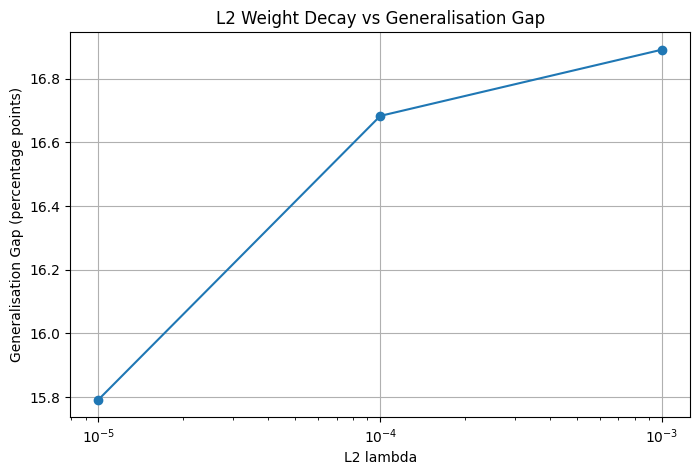

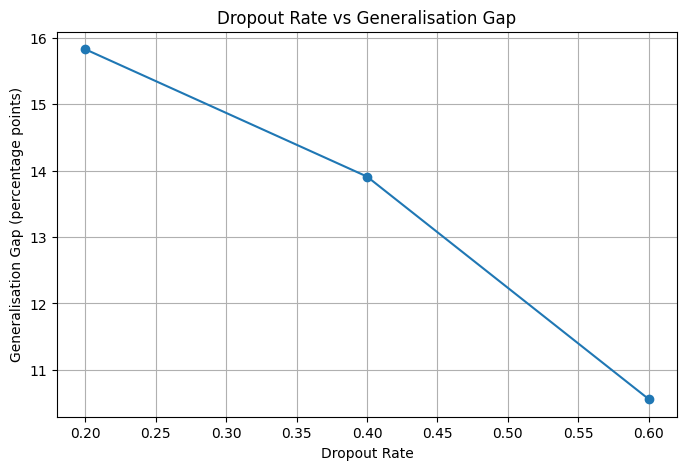



BEST RESULT


Method: Early stopping
Setting: patience=5, stopped epoch=9
Train accuracy: 86.25%
Validation accuracy: 78.99%
Generalisation gap: 7.26%


In [12]:

import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\n")
print("PART 6: REGULARISATION STUDY")
print("\n")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available. Using CPU.")


BATCH_SIZE = 64
LEARNING_RATE = 0.001
MAX_EPOCHS = 100


X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.long
)


if len(X_val_tensor.shape) > 2:
    X_val_tensor = X_val_tensor.view(
        X_val_tensor.size(0),
        -1
    )


X_val_tensor = X_val_tensor.to(device)
y_val_tensor = y_val_tensor.to(device)


class RegularizationMLP(nn.Module):

    def __init__(self, dropout_rate=0.0, batch_norm=False):
        super().__init__()

        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 512)
        self.fc4 = nn.Linear(512, 512)
        self.output = nn.Linear(512, 10)

        self.batch_norm = batch_norm

        if batch_norm:
            self.bn1 = nn.BatchNorm1d(512)
            self.bn2 = nn.BatchNorm1d(512)
            self.bn3 = nn.BatchNorm1d(512)
            self.bn4 = nn.BatchNorm1d(512)

        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):

        x = torch.relu(self.fc1(x))

        if self.batch_norm:
            x = self.bn1(x)

        x = self.dropout(x)

        x = torch.relu(self.fc2(x))

        if self.batch_norm:
            x = self.bn2(x)

        x = self.dropout(x)

        x = torch.relu(self.fc3(x))

        if self.batch_norm:
            x = self.bn3(x)

        x = self.dropout(x)

        x = torch.relu(self.fc4(x))

        if self.batch_norm:
            x = self.bn4(x)

        x = self.dropout(x)

        x = self.output(x)

        return x


def calculate_accuracy(model, X, y):

    model.eval()

    with torch.no_grad():

        outputs = model(X)
        predictions = torch.argmax(outputs, dim=1)

        accuracy = (predictions == y).float().mean()

    return accuracy.item() * 100



def train_regularized_model(
    X_train_data,
    y_train_data,
    dropout_rate=0.0,
    batch_norm=False,
    l2_lambda=0.0,
    l1_lambda=0.0,
    augmentation=False,
    early_stopping=False,
    patience=5
):

    model = RegularizationMLP(
        dropout_rate=dropout_rate,
        batch_norm=batch_norm
    ).to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=l2_lambda
    )

    criterion = nn.CrossEntropyLoss()

    dataset = TensorDataset(
        X_train_data,
        y_train_data
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    best_val_loss = float("inf")
    patience_counter = 0

    final_train_acc = 0
    final_val_acc = 0

    for epoch in range(MAX_EPOCHS):

        model.train()

        total_loss = 0

        for batch_X, batch_y in loader:

            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)


            if augmentation:

                images = batch_X.view(
                    -1, 1, 28, 28
                )


                flip_mask = torch.rand(
                    images.size(0),
                    device=device
                ) < 0.5

                images[flip_mask] = torch.flip(
                    images[flip_mask],
                    dims=[3]
                )


                try:

                    from torchvision.transforms.functional import rotate

                    angles = torch.empty(
                        images.size(0),
                        device=device
                    ).uniform_(-10, 10)

                    rotated_images = []

                    for i in range(images.size(0)):

                        rotated_image = rotate(
                            images[i],
                            float(angles[i])
                        )

                        rotated_images.append(
                            rotated_image
                        )

                    images = torch.stack(
                        rotated_images
                    )

                except ImportError:

                    pass

                batch_X = images.view(
                    -1,
                    784
                )

            optimizer.zero_grad()

            outputs = model(batch_X)

            loss = criterion(
                outputs,
                batch_y
            )

            if l1_lambda > 0:

                l1_penalty = 0

                for parameter in model.parameters():

                    l1_penalty += torch.sum(
                        torch.abs(parameter)
                    )

                loss = loss + (
                    l1_lambda * l1_penalty
                )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        model.eval()

        with torch.no_grad():

            train_outputs = model(
                X_train_data
            )

            val_outputs = model(
                X_val_tensor
            )

            train_loss = criterion(
                train_outputs,
                y_train_data
            ).item()

            val_loss = criterion(
                val_outputs,
                y_val_tensor
            ).item()

        train_acc = calculate_accuracy(
            model,
            X_train_data,
            y_train_data
        )

        val_acc = calculate_accuracy(
            model,
            X_val_tensor,
            y_val_tensor
        )

        final_train_acc = train_acc
        final_val_acc = val_acc

        print(
            f"Epoch {epoch + 1:3d}/{MAX_EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Val Acc: {val_acc:.2f}%"
        )

        if early_stopping:

            if val_loss < best_val_loss:

                best_val_loss = val_loss
                patience_counter = 0

            else:

                patience_counter += 1

            if patience_counter >= patience:

                print(
                    f"\nEarly stopping at epoch "
                    f"{epoch + 1}"
                )

                break

        if not early_stopping and train_acc >= 99:

            print(
                "\nTraining accuracy exceeded 99%."
            )

            print(
                f"Stopping at epoch {epoch + 1}."
            )

            break

    return (
        model,
        final_train_acc,
        final_val_acc,
        epoch + 1
    )


X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)


if len(X_train_tensor.shape) > 2:

    X_train_tensor = X_train_tensor.view(
        X_train_tensor.size(0),
        -1
    )

X_train_tensor = X_train_tensor.to(device)
y_train_tensor = y_train_tensor.to(device)


X_2000 = X_train_tensor[:2000]
y_2000 = y_train_tensor[:2000]


results = []

l2_results = []
dropout_results = []


def add_result(
    method,
    setting,
    train_acc,
    val_acc
):

    gap = train_acc - val_acc

    results.append({
        "Method": method,
        "Setting": setting,
        "Train accuracy": train_acc,
        "Validation accuracy": val_acc,
        "Gap": gap
    })


print("\n" + "=" * 70)
print("BASELINE")
print("=" * 70)

model, train_acc, val_acc, epochs = train_regularized_model(
    X_2000,
    y_2000
)

add_result(
    "Baseline (no regularisation)",
    "-",
    train_acc,
    val_acc
)

print(f"\nTrain accuracy: {train_acc:.2f}%")
print(f"Validation accuracy: {val_acc:.2f}%")
print(f"Gap: {train_acc - val_acc:.2f}%")


print("\n" + "=" * 70)
print("L2 WEIGHT DECAY")
print("=" * 70)

l2_values = [
    1e-5,
    1e-4,
    1e-3
]

for value in l2_values:

    print(f"\nL2 lambda = {value}")

    model, train_acc, val_acc, epochs = train_regularized_model(
        X_2000,
        y_2000,
        l2_lambda=value
    )

    gap = train_acc - val_acc

    add_result(
        "L2 weight decay",
        str(value),
        train_acc,
        val_acc
    )

    l2_results.append(
        (value, gap)
    )

    print(f"Train accuracy: {train_acc:.2f}%")
    print(f"Validation accuracy: {val_acc:.2f}%")
    print(f"Gap: {gap:.2f}%")


print("\n" + "=" * 70)
print("L1 PENALTY")
print("=" * 70)

l1_values = [
    1e-6,
    1e-5,
    1e-4
]

for value in l1_values:

    print(f"\nL1 lambda = {value}")

    model, train_acc, val_acc, epochs = train_regularized_model(
        X_2000,
        y_2000,
        l1_lambda=value
    )

    total_weights = 0
    small_weights = 0

    for parameter in model.parameters():

        weights = parameter.detach().cpu().numpy()

        total_weights += weights.size

        small_weights += np.sum(
            np.abs(weights) < 1e-3
        )

    percentage_small = (
        small_weights / total_weights
    ) * 100

    setting = (
        f"lambda={value}, "
        f"weights <1e-3="
        f"{percentage_small:.2f}%"
    )

    add_result(
        "L1 penalty",
        setting,
        train_acc,
        val_acc
    )

    print(f"Train accuracy: {train_acc:.2f}%")
    print(f"Validation accuracy: {val_acc:.2f}%")
    print(f"Gap: {train_acc - val_acc:.2f}%")
    print(
        f"Weights below 1e-3: "
        f"{percentage_small:.2f}%"
    )

print("\n")
print("DROPOUT")
print("\n")

dropout_values = [
    0.2,
    0.4,
    0.6
]

for value in dropout_values:

    print(f"\nDropout rate = {value}")

    model, train_acc, val_acc, epochs = train_regularized_model(
        X_2000,
        y_2000,
        dropout_rate=value
    )

    gap = train_acc - val_acc

    add_result(
        "Dropout",
        str(value),
        train_acc,
        val_acc
    )

    dropout_results.append(
        (value, gap)
    )

    print(f"Train accuracy: {train_acc:.2f}%")
    print(f"Validation accuracy: {val_acc:.2f}%")
    print(f"Gap: {gap:.2f}%")


print("\n")
print("BATCH NORMALISATION")
print("\n")

model, train_acc, val_acc, epochs = train_regularized_model(
    X_2000,
    y_2000,
    batch_norm=True
)

add_result(
    "Batch normalisation",
    "BatchNorm after hidden layers",
    train_acc,
    val_acc
)

print(f"\nTrain accuracy: {train_acc:.2f}%")
print(f"Validation accuracy: {val_acc:.2f}%")
print(f"Gap: {train_acc - val_acc:.2f}%")


print("\n" + "=" * 70)
print("EARLY STOPPING")
print("=" * 70)

PATIENCE = 5

model, train_acc, val_acc, epochs = train_regularized_model(
    X_2000,
    y_2000,
    early_stopping=True,
    patience=PATIENCE
)

add_result(
    "Early stopping",
    f"patience={PATIENCE}, "
    f"stopped epoch={epochs}",
    train_acc,
    val_acc
)

print(f"\nPatience: {PATIENCE}")
print(f"Stopped at epoch: {epochs}")
print(f"Train accuracy: {train_acc:.2f}%")
print(f"Validation accuracy: {val_acc:.2f}%")
print(f"Gap: {train_acc - val_acc:.2f}%")


print("\n" + "=" * 70)
print("DATA AUGMENTATION")
print("=" * 70)

model, train_acc, val_acc, epochs = train_regularized_model(
    X_2000,
    y_2000,
    augmentation=True
)

add_result(
    "Data augmentation",
    "Horizontal flip + rotation ±10°",
    train_acc,
    val_acc
)

print(f"\nTrain accuracy: {train_acc:.2f}%")
print(f"Validation accuracy: {val_acc:.2f}%")
print(f"Gap: {train_acc - val_acc:.2f}%")

print("\n")
print("MORE TRAINING DATA: 10,000")
print("\n")

X_10000 = X_train_tensor[:10000]
y_10000 = y_train_tensor[:10000]

model, train_acc, val_acc, epochs = train_regularized_model(
    X_10000,
    y_10000
)

add_result(
    "More training data",
    "10,000 samples",
    train_acc,
    val_acc
)

print(f"\nTrain accuracy: {train_acc:.2f}%")
print(f"Validation accuracy: {val_acc:.2f}%")
print(f"Gap: {train_acc - val_acc:.2f}%")


print("\n")
print("MORE TRAINING DATA: 20,000")
print("\n")

X_20000 = X_train_tensor[:20000]
y_20000 = y_train_tensor[:20000]

model, train_acc, val_acc, epochs = train_regularized_model(
    X_20000,
    y_20000
)

add_result(
    "More training data",
    "20,000 samples",
    train_acc,
    val_acc
)

print(f"\nTrain accuracy: {train_acc:.2f}%")
print(f"Validation accuracy: {val_acc:.2f}%")
print(f"Gap: {train_acc - val_acc:.2f}%")

print("\n")
print("PART 6 FINAL RESULTS")
print("\n")

print(
    f"{'Method':<30}"
    f"{'Setting':<35}"
    f"{'Train Acc':>12}"
    f"{'Val Acc':>12}"
    f"{'Gap':>12}"
)

print("-" * 100)

for result in results:

    print(
        f"{result['Method']:<30}"
        f"{result['Setting']:<35}"
        f"{result['Train accuracy']:>11.2f}%"
        f"{result['Validation accuracy']:>11.2f}%"
        f"{result['Gap']:>11.2f}%"
    )


l2_x = [
    x[0]
    for x in l2_results
]

l2_y = [
    x[1]
    for x in l2_results
]

plt.figure(figsize=(8, 5))

plt.plot(
    l2_x,
    l2_y,
    marker="o"
)

plt.xscale("log")

plt.xlabel("L2 lambda")
plt.ylabel(
    "Generalisation Gap "
    "(percentage points)"
)

plt.title(
    "L2 Weight Decay vs Generalisation Gap"
)

plt.grid(True)

plt.show()


dropout_x = [
    x[0]
    for x in dropout_results
]

dropout_y = [
    x[1]
    for x in dropout_results
]

plt.figure(figsize=(8, 5))

plt.plot(
    dropout_x,
    dropout_y,
    marker="o"
)

plt.xlabel("Dropout Rate")

plt.ylabel(
    "Generalisation Gap "
    "(percentage points)"
)

plt.title(
    "Dropout Rate vs Generalisation Gap"
)

plt.grid(True)

plt.show()


best_result = min(
    results,
    key=lambda x: x["Gap"]
)

print("\n")
print("BEST RESULT")
print("\n")

print(
    f"Method: "
    f"{best_result['Method']}"
)

print(
    f"Setting: "
    f"{best_result['Setting']}"
)

print(
    f"Train accuracy: "
    f"{best_result['Train accuracy']:.2f}%"
)

print(
    f"Validation accuracy: "
    f"{best_result['Validation accuracy']:.2f}%"
)

print(
    f"Generalisation gap: "
    f"{best_result['Gap']:.2f}%"
)

if torch.cuda.is_available():
    torch.cuda.empty_cache()

Comparison

Out of all the methods, early stopping gave the biggest drop in the gap (from 16.74% down to 7.26%), but it came at a real cost — training accuracy fell all the way to 86.25% since the model basically stopped learning early, before it could even fit the data properly. Dropout with rate 0.6 also helped a lot (gap went down to 10.56%) without losing as much train accuracy, but it still took a noticeable hit.

The one that actually balanced things out best was just adding more data. With 20,000 samples, the gap dropped to 11.85% while train accuracy barely changed at all (99.50% to 99.26%, basically nothing lost). So even though early stopping technically got the smallest gap, more training data gave the best result for the least damage to performance which means it's the one that actually feels like a "free" fix rather than a trade-off.

Using device: cpu
SEARCH SPACE
learning_rate : log-uniform [1e-4, 1e-2]
hidden_width  : {64, 128, 256, 512}
dropout_rate  : uniform [0.0, 0.5]

Generated 12 random configurations:

Config  1: lr=0.00353, hidden_width=256, dropout=0.429
Config  2: lr=0.00248, hidden_width=128, dropout=0.047
Config  3: lr=0.00894, hidden_width=256, dropout=0.393
Config  4: lr=0.00018, hidden_width=512, dropout=0.225
Config  5: lr=0.00055, hidden_width=64, dropout=0.322
Config  6: lr=0.00442, hidden_width=512, dropout=0.222
Config  7: lr=0.00028, hidden_width=64, dropout=0.032
Config  8: lr=0.00452, hidden_width=256, dropout=0.316
Config  9: lr=0.00328, hidden_width=256, dropout=0.485
Config 10: lr=0.00611, hidden_width=128, dropout=0.389
Config 11: lr=0.00025, hidden_width=128, dropout=0.022
Config 12: lr=0.00020, hidden_width=128, dropout=0.342
RUNNING RANDOM SEARCH WITH 5-FOLD CV

Config  1/12 | lr=0.00353 | hidden=256 | dropout=0.429 | CV Acc: 87.11% (+/- 0.59%)
Config  2/12 | lr=0.00248 | hidden=128 

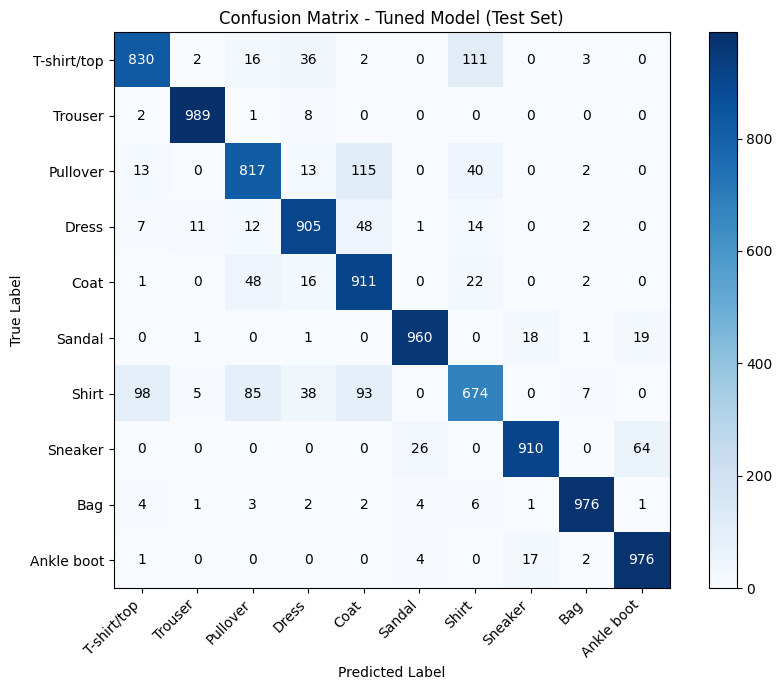

RETRAINING PART 2 BASELINE FOR COMPARISON


COMPARISON WITH PART 2 BASELINE
Part 2 baseline test accuracy : 89.41%
Tuned model test accuracy     : 89.48%
Improvement                   : +0.07 percentage points


In [15]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

np.random.seed(42)
torch.manual_seed(42)

N_CONFIGS = 12

def sample_config(rng):
    lr = 10 ** rng.uniform(-4, -2)
    hidden_width = rng.choice([64, 128, 256, 512])
    dropout_rate = rng.uniform(0.0, 0.5)
    return {
        "learning_rate": lr,
        "hidden_width": int(hidden_width),
        "dropout_rate": dropout_rate
    }

rng = np.random.default_rng(42)
configs = [sample_config(rng) for _ in range(N_CONFIGS)]

print("SEARCH SPACE")
print("learning_rate : log-uniform [1e-4, 1e-2]")
print("hidden_width  : {64, 128, 256, 512}")
print("dropout_rate  : uniform [0.0, 0.5]")
print(f"\nGenerated {N_CONFIGS} random configurations:\n")
for i, c in enumerate(configs):
    print(f"Config {i+1:2d}: lr={c['learning_rate']:.5f}, "
          f"hidden_width={c['hidden_width']}, "
          f"dropout={c['dropout_rate']:.3f}")


class TunableMLP(nn.Module):
    def __init__(self, hidden_width, dropout_rate):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, hidden_width),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_width, hidden_width // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_width // 2, 10)
        )

    def forward(self, x):
        return self.net(x)


def train_one_fold(X_tr, y_tr, X_va, y_va, config, epochs=10, batch_size=256):

    torch.manual_seed(42)

    model = TunableMLP(config["hidden_width"], config["dropout_rate"]).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])
    criterion = nn.CrossEntropyLoss()

    train_ds = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.long)
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    X_va_t = torch.tensor(X_va, dtype=torch.float32).to(device)
    y_va_t = torch.tensor(y_va, dtype=torch.long).to(device)

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = torch.argmax(model(X_va_t), dim=1)
        acc = (preds == y_va_t).float().mean().item()

    return acc


def cross_validate_config(config, X, y, n_splits=5):

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_scores = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_va = X[train_idx], X[val_idx]
        y_tr, y_va = y[train_idx], y[val_idx]

        acc = train_one_fold(X_tr, y_tr, X_va, y_va, config)
        fold_scores.append(acc)

    return np.mean(fold_scores), np.std(fold_scores)

results = []

print("RUNNING RANDOM SEARCH WITH 5-FOLD CV\n")

for i, config in enumerate(configs):
    mean_acc, std_acc = cross_validate_config(config, X_train, y_train, n_splits=5)
    results.append({
        "config": config,
        "mean_cv_acc": mean_acc,
        "std_cv_acc": std_acc
    })
    print(f"Config {i+1:2d}/{N_CONFIGS} | lr={config['learning_rate']:.5f} | "
          f"hidden={config['hidden_width']:3d} | dropout={config['dropout_rate']:.3f} "
          f"| CV Acc: {mean_acc*100:.2f}% (+/- {std_acc*100:.2f}%)")

results_sorted = sorted(results, key=lambda r: r["mean_cv_acc"], reverse=True)

print("\nTOP 5 CONFIGURATIONS\n")
print(f"{'Rank':<5}{'LR':<10}{'Hidden':<8}{'Dropout':<9}{'Mean CV Acc':<14}{'Std':<8}")
for rank, r in enumerate(results_sorted[:5], start=1):
    c = r["config"]
    print(f"{rank:<5}{c['learning_rate']:<10.5f}{c['hidden_width']:<8}"
          f"{c['dropout_rate']:<9.3f}{r['mean_cv_acc']*100:<14.2f}{r['std_cv_acc']*100:<8.2f}")

best_config = results_sorted[0]["config"]
print("\nSELECTED CONFIGURATION")
print(best_config)

torch.manual_seed(42)

final_model = TunableMLP(best_config["hidden_width"], best_config["dropout_rate"]).to(device)
optimizer = torch.optim.Adam(final_model.parameters(), lr=best_config["learning_rate"])
criterion = nn.CrossEntropyLoss()

full_train_ds = TensorDataset(
    torch.tensor(X_full, dtype=torch.float32),
    torch.tensor(y_full, dtype=torch.long)
)
full_train_loader = DataLoader(full_train_ds, batch_size=256, shuffle=True)

FINAL_EPOCHS = 30

print("RETRAINING SELECTED CONFIGURATION ON FULL TRAINING SET\n")

for epoch in range(FINAL_EPOCHS):
    final_model.train()
    total_loss = 0
    for xb, yb in full_train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(final_model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)

    epoch_loss = total_loss / len(full_train_ds)
    print(f"Epoch {epoch+1:2d}/{FINAL_EPOCHS} | Loss: {epoch_loss:.4f}")

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

final_model.eval()
with torch.no_grad():
    preds = torch.argmax(final_model(X_test_t), dim=1).cpu().numpy()

y_true = y_test

test_accuracy = accuracy_score(y_true, preds)
macro_precision = precision_score(y_true, preds, average="macro")
macro_recall = recall_score(y_true, preds, average="macro")
macro_f1 = f1_score(y_true, preds, average="macro")

print("\nTEST SET RESULTS (TUNED MODEL)")
print(f"Accuracy        : {test_accuracy*100:.2f}%")
print(f"Macro Precision : {macro_precision*100:.2f}%")
print(f"Macro Recall    : {macro_recall*100:.2f}%")
print(f"Macro F1        : {macro_f1*100:.2f}%")

cm = confusion_matrix(y_true, preds)

plt.figure(figsize=(9, 7))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(10), class_names, rotation=45, ha="right")
plt.yticks(range(10), class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Tuned Model (Test Set)")

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                  color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.show()

class BaselineMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.net(x)


torch.manual_seed(42)
baseline_model = BaselineMLP().to(device)
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

baseline_train_loader = DataLoader(full_train_ds, batch_size=128, shuffle=True)

print("RETRAINING PART 2 BASELINE FOR COMPARISON\n")

for epoch in range(20):
    baseline_model.train()
    for xb, yb in baseline_train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(baseline_model(xb), yb)
        loss.backward()
        optimizer.step()

baseline_model.eval()
with torch.no_grad():
    baseline_preds = torch.argmax(baseline_model(X_test_t), dim=1).cpu().numpy()

baseline_accuracy = accuracy_score(y_true, baseline_preds)

improvement = (test_accuracy - baseline_accuracy) * 100

print("\nCOMPARISON WITH PART 2 BASELINE")
print(f"Part 2 baseline test accuracy : {baseline_accuracy*100:.2f}%")
print(f"Tuned model test accuracy     : {test_accuracy*100:.2f}%")
print(f"Improvement                   : {improvement:+.2f} percentage points")

Improvement

The tuned model scored 89.48% vs the baseline's 89.41% which means a gain of just +0.07 percentage points, which is negligible. This is likely because the selected config (hidden=128, dropout=0.047, lr=0.00248) landed very close to the baseline's own settings, leaving little room for tuning to help. This suggests the simple MLP architecture is near its ceiling on Fashion-MNIST, and further gains would need a different model type rather than better hyperparameters.